# NLP et Deep Learning : Sémantique Fine et Nommage Automatique

## Objectif
Ce notebook explore des méthodes avancées pour capturer la sémantique des jeux en utilisant le **Traitement du Langage Naturel (NLP)** et le **Deep Learning**. 

Nous allons :
1.  Utiliser des **Embeddings** (BERT via Sentence-Transformers) pour représenter les tags dans un espace vectoriel riche.
2.  S'appuyer sur le clustering de Louvain pour identifier des groupes cohérents.
3.  **Nommer automatiquement les clusters** en calculant le centroïde des embeddings et en trouvant le terme le plus représentatif.
4.  **Analyser la cohérence** des clusters et visualiser leurs relations.

Ces étapes permettent de passer d'une simple liste de tags à une véritable compréhension thématique et structurelle.

In [8]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import os
plt.rcParams.update({
    'figure.facecolor': 'white', 
    'axes.facecolor': 'white', 
    'savefig.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'figure.autolayout': True
})
def save_plot(name):
    if not os.path.exists('figures'): os.makedirs('figures')
    plt.gcf().canvas.draw()
    plt.savefig(f'figures/7_{name}.png', bbox_inches='tight', facecolor='white', dpi=300)
import seaborn as sns
import warnings
import logging
import os

# 1. Configuration pour un affichage propre
warnings.filterwarnings("ignore")
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)
sns.set_style("whitegrid")

# 2. Chargement et Préparation des Données
df_structured = pd.read_csv('../data/Games_Gameplay_Taxonomy.csv')
df_tags = df_structured[['game_id', 'Genre', 'Mechanics']].copy()
df_tags['all_tags'] = df_tags['Genre'].fillna('') + ', ' + df_tags['Mechanics'].fillna('')
df_tags['all_tags'] = df_tags['all_tags'].str.strip(', ')

tags_exploded = df_tags.assign(tag=df_tags['all_tags'].str.split(', ')).explode('tag')
tags_exploded = tags_exploded[tags_exploded['tag'].notna() & (tags_exploded['tag'] != '')]

tag_counts = tags_exploded['tag'].value_counts()
frequent_tags = tag_counts[tag_counts > 500].index
tags_filtered = tags_exploded[tags_exploded['tag'].isin(frequent_tags)]

matrix = pd.get_dummies(tags_filtered['tag']).astype(int)
matrix['game_id'] = tags_filtered['game_id'].values
matrix = matrix.groupby('game_id').max()

# Similarité Cosinus sur la présence des tags
tag_sim_matrix = cosine_similarity(matrix.T)
df_sim_presence = pd.DataFrame(tag_sim_matrix, index=matrix.columns, columns=matrix.columns)

## 2. Clustering de Louvain (ou Chargement)
Nous tentons de charger les clusters définis dans le notebook précédent (Folksonomic Clustering) pour assurer la continuité. Si le fichier n'existe pas, nous recalculons les clusters.

In [9]:
# Tentative de chargement des clusters existants depuis l'analyse précédente
clusters = {}
leaders_v4 = {}
use_existing_clusters = False

try:
    df_clusters_v4 = pd.read_csv('../data/Folksonomic_Clusters.csv')
    print("✅ Chargement des clusters depuis Folksonomic_Clusters.csv")

    # Reconstruction du dictionnaire des clusters
    for index, row in df_clusters_v4.iterrows():
        cid = row['Cluster']
        tag = row['Tag']

        # Ignorer le bruit si présent (souvent -1)
        if cid == -1:
            continue

        if cid not in clusters:
            clusters[cid] = []
        clusters[cid].append(tag)

        # Récupération du leader identifié par centralité (Notebook 4)
        if 'Leader' in row and pd.notna(row['Leader']):
             leaders_v4[cid] = row['Leader']

    use_existing_clusters = True
    print(f"Nombre de clusters chargés : {len(clusters)}")

except FileNotFoundError:
    print("⚠️ Folksonomic_Clusters.csv non trouvé. Recalcul des clusters (Louvain)...")

    G = nx.Graph()
    threshold = 0.20
    tags = df_sim_presence.columns
    for i in range(len(tags)):
        for j in range(i + 1, len(tags)):
            sim = tag_sim_matrix[i, j]
            if sim > threshold:
                G.add_edge(tags[i], tags[j], weight=sim)

    # Ajout de random_state pour la reproductibilité
    partition = community_louvain.best_partition(G, weight='weight', random_state=42)

    clusters = {}
    for tag, community_id in partition.items():
        if community_id not in clusters:
            clusters[community_id] = []
        clusters[community_id].append(tag)

    # Calcul des leaders par centralité si on recalcule
    degree_centrality = nx.degree_centrality(G)
    for cid, tags_in_cluster in clusters.items():
        leader = sorted(tags_in_cluster, key=lambda x: degree_centrality.get(x, 0), reverse=True)[0]
        leaders_v4[cid] = leader

    print(f"Nombre de clusters détectés : {len(clusters)}")

✅ Chargement des clusters depuis Folksonomic_Clusters.csv
Nombre de clusters chargés : 42


## 3. Embeddings et Nommage Automatique Amélioré

Nous utilisons un modèle **BERT** plus avancé (`all-mpnet-base-v2`) pour transformer chaque tag en vecteur. Nous comparons ensuite le "Leader" identifié par centralité de graphe (Notebook 4) avec le "Leader" sémantique (celui qui est le plus proche du centre de gravité du cluster).

In [10]:
print("Chargement du modèle d'embeddings avancé (all-mpnet-base-v2)...")
# Amélioration 1 : Utilisation d'un modèle plus performant
model = SentenceTransformer('all-mpnet-base-v2')

# Calcul des embeddings pour tous les tags fréquents
unique_tags = list(matrix.columns)
tag_embeddings = model.encode(unique_tags)
df_embeddings = pd.DataFrame(tag_embeddings, index=unique_tags)

def get_cluster_name_enhanced(cluster_tags, all_tag_embeddings, top_k=3):
    # Calcul du centroïde (moyenne des vecteurs du cluster)
    cluster_vecs = all_tag_embeddings.loc[cluster_tags]
    centroid = cluster_vecs.mean(axis=0).values.reshape(1, -1)
    
    # Recherche des tags les plus proches du centroïde
    similarities = cosine_similarity(centroid, all_tag_embeddings.values)

    # Top K indices
    top_indices = np.argsort(similarities[0])[::-1][:top_k]
    top_tags = [unique_tags[i] for i in top_indices]

    return top_tags[0], top_tags # Retourne le meilleur et la liste des top_k

cluster_names_nlp = {}
comparison_data = []

print("\n--- Comparaison des Leaders : Centralité (Graphe) vs Sémantique (NLP) ---")

for cid in sorted(clusters.keys()):
    tags_in_cluster = clusters[cid]

    # Nommage NLP
    best_name, top_names = get_cluster_name_enhanced(tags_in_cluster, df_embeddings)
    cluster_names_nlp[cid] = best_name

    # Leader Graphe (V4)
    leader_graph = leaders_v4.get(cid, "N/A")

    # Comparaison
    match = "✅" if leader_graph == best_name else "❌"

    comparison_data.append({
        'Cluster ID': cid,
        'Nb Tags': len(tags_in_cluster),
        'Leader Graph (Centralité)': leader_graph,
        'Leader NLP (Sémantique)': best_name,
        'Top 3 NLP': ", ".join(top_names),
        'Match': match,
        'Exemple Tags': ", ".join(tags_in_cluster[:5])
    })

df_comparison = pd.DataFrame(comparison_data)
pd.set_option('display.max_colwidth', None)
print(df_comparison[['Cluster ID', 'Leader Graph (Centralité)', 'Leader NLP (Sémantique)', 'Match']].to_string(index=False))

# Sauvegarde de la comparaison
df_comparison.to_csv('../data/Clusters_Leaders_Comparison.csv', index=False)
print("\nComparaison sauvegardée dans '../data/Clusters_Leaders_Comparison.csv'")

Chargement du modèle d'embeddings avancé (all-mpnet-base-v2)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


--- Comparaison des Leaders : Centralité (Graphe) vs Sémantique (NLP) ---
 Cluster ID Leader Graph (Centralité)   Leader NLP (Sémantique) Match
          0         Time Manipulation         Time Manipulation     ✅
          1                    Action                Platformer     ❌
          2                       RTS                Action RTS     ❌
          3                      6DOF                      6DOF     ✅
          4                  Fighting                2D Fighter     ❌
          5                  Strategy              Strategy RPG     ❌
          6                 Word Game                 Word Game     ✅
          7   Artificial Intelligence   Artificial Intelligence     ✅
          8              Auto Battler              Auto Battler     ✅
          9                  Building                Colony Sim     ❌
         10            Automobile Sim            Automobile Sim     ✅
         11             Battle Royale             Battle Royale     ✅
         12    

*Dans la globalité, les leaders identifiés par centralité de graphe et par sémantique NLP sont souvent proches, mais il y a des cas où ils diffèrent, ce qui peut indiquer des nuances dans la compréhension thématique du cluster. Par exemple, un cluster pourrait être centré autour d'un tag très fréquent (leader de graphe) mais le tag le plus sémantiquement représentatif pourrait être un terme plus spécifique ou plus descriptif (leader NLP), c'est notamment le cas pour 'Action' dont le leader sémantique est 'Platformer' qui est plus spécifique que 'Action' qui est un terme très générique.*

## 4. Visualisation Sémantique Avancée (t-SNE)
Nous projetons les embeddings sémantiques en 2D pour visualiser la cohérence des clusters.


Calcul du t-SNE sur les embeddings sémantiques...


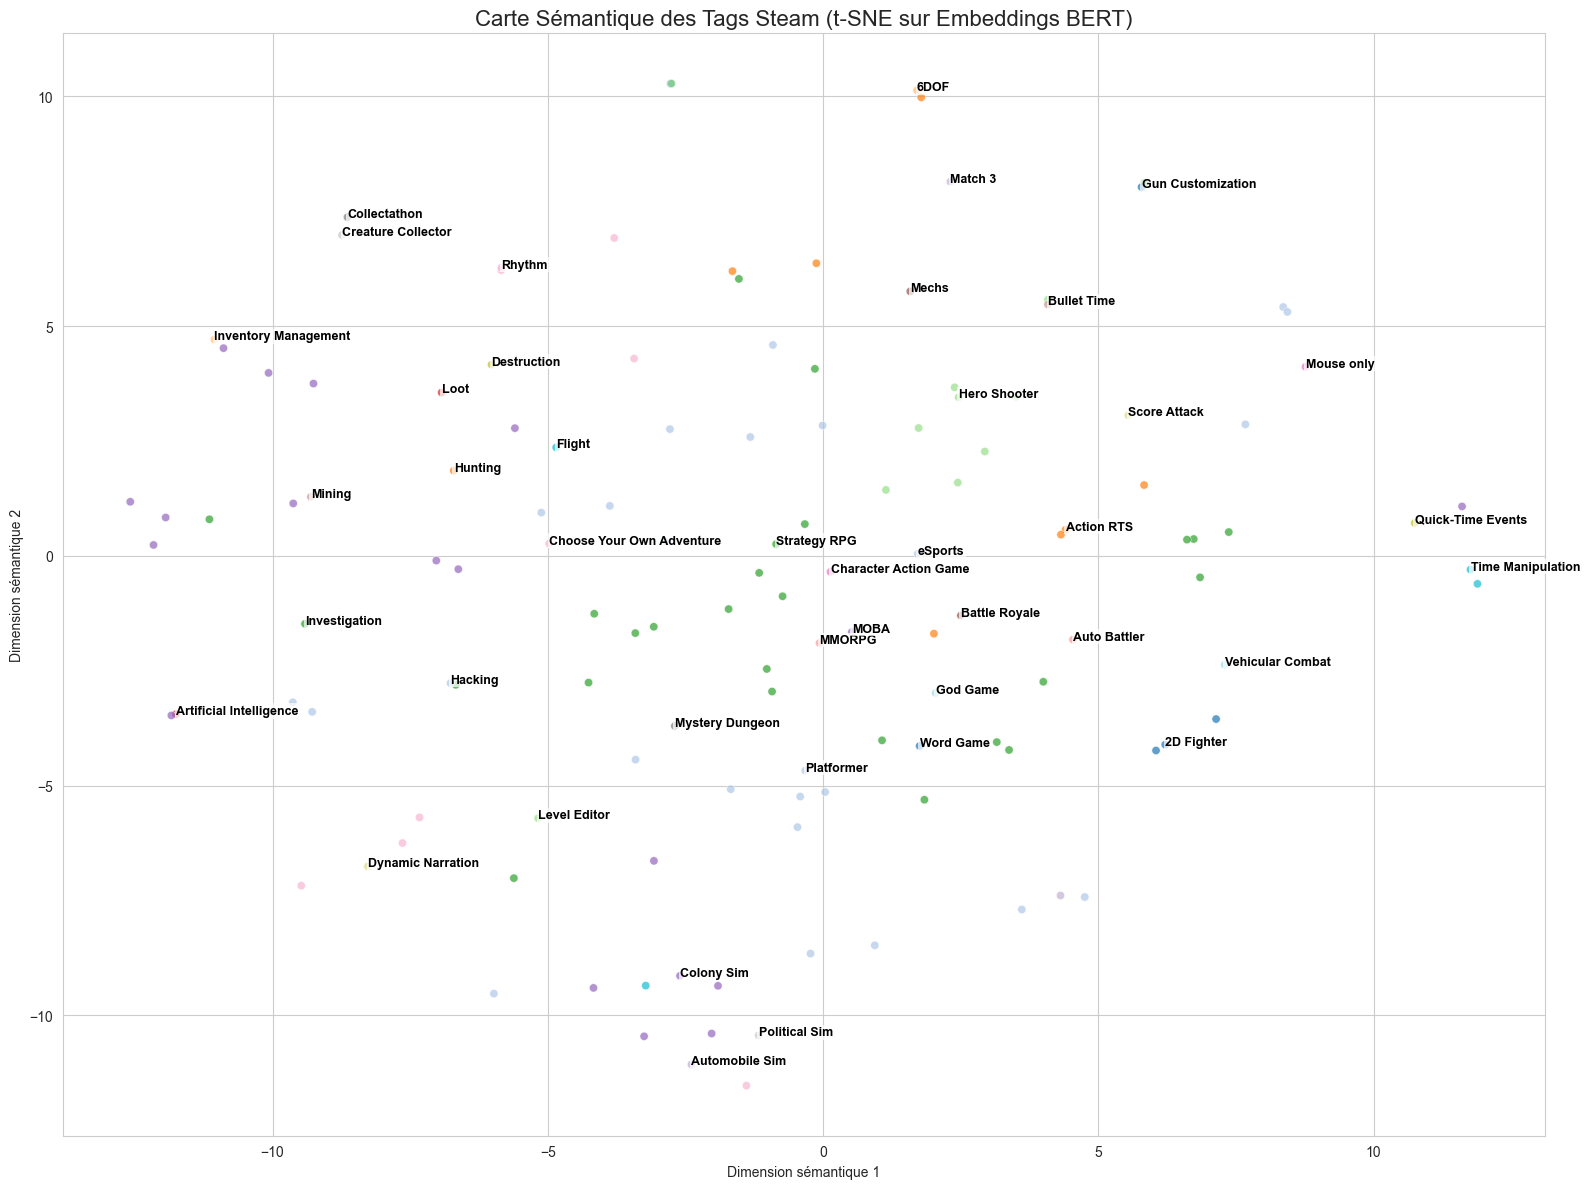

In [11]:
print("\nCalcul du t-SNE sur les embeddings sémantiques...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
embeddings_2d = tsne.fit_transform(tag_embeddings)

df_tsne = pd.DataFrame(embeddings_2d, columns=['x', 'y'], index=unique_tags)
df_tsne['Cluster'] = df_tsne.index.map(lambda tag: next((cid for cid, tags in clusters.items() if tag in tags), -1))
df_tsne['Leader_NLP'] = df_tsne['Cluster'].map(cluster_names_nlp)

plt.figure(figsize=(16, 12))
# Filtrer le bruit si nécessaire
df_plot = df_tsne[df_tsne['Cluster'] != -1]

sns.scatterplot(
    data=df_plot,
    x='x', y='y',
    hue='Leader_NLP',
    palette='tab20',
    legend=False,
    alpha=0.7
)

# Annoter les leaders
for cid, leader in cluster_names_nlp.items():
    if leader in df_tsne.index:
        row = df_tsne.loc[leader]
        plt.text(row['x'], row['y'], leader, fontsize=9, weight='bold', color='black',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

plt.title("Carte Sémantique des Tags Steam (t-SNE sur Embeddings BERT)", fontsize=16)
plt.xlabel("Dimension sémantique 1")
plt.ylabel("Dimension sémantique 2")
save_plot('plot')
plt.show()

## 5. Analyse Sémantique Approfondie
Nous allons maintenant quantifier la qualité des clusters et explorer leurs relations.
1. **Cohérence Intra-Cluster** : Variance des distances au centroïde.
2. **Détection d'Outliers** : Tags qui semblent mal classés sémantiquement.
3. **Similarité Inter-Cluster** : Quels genres sont proches les uns des autres ?

In [12]:
from sklearn.metrics import silhouette_score

print("\n--- Analyse de la Cohérence Sémantique ---")

# 1. Préparation des données pour l'analyse
tag_to_cluster = {}
for cid, tags in clusters.items():
    for tag in tags:
        tag_to_cluster[tag] = cid

valid_tags = [tag for tag in unique_tags if tag in tag_to_cluster]
valid_embeddings = df_embeddings.loc[valid_tags]
labels = [tag_to_cluster[tag] for tag in valid_tags]

# 2. Silhouette Score
# Le score de silhouette mesure à quel point un objet est similaire à son propre cluster (cohésion)
# comparé aux autres clusters (séparation).
sil_score = silhouette_score(valid_embeddings, labels, metric='cosine')
print(f"Silhouette Score Global : {sil_score:.4f} (Plus proche de 1 est mieux)")

# 3. Variance Intra-Cluster et Outliers
cluster_stats = []
outliers = []

for cid in sorted(clusters.keys()):
    tags_in_cluster = clusters[cid]
    if len(tags_in_cluster) < 2:
        continue

    cluster_vecs = df_embeddings.loc[tags_in_cluster]
    centroid = cluster_vecs.mean(axis=0).values.reshape(1, -1)

    # Distances cosine au centroïde (0 = identique, 1 = opposé)
    dists = 1 - cosine_similarity(cluster_vecs, centroid).flatten()

    variance = np.mean(dists)

    # Détection Outliers : distance > mean + 2*std
    threshold = np.mean(dists) + 2 * np.std(dists)
    outlier_indices = np.where(dists > threshold)[0]

    for idx in outlier_indices:
        outliers.append({
            'Cluster': cid,
            'Leader': cluster_names_nlp.get(cid, 'N/A'),
            'Outlier Tag': tags_in_cluster[idx],
            'Distance': dists[idx]
        })

    cluster_stats.append({
        'Cluster ID': cid,
        'Leader': cluster_names_nlp.get(cid, 'N/A'),
        'Size': len(tags_in_cluster),
        'Intra-Cluster Variance': variance
    })

df_cluster_stats = pd.DataFrame(cluster_stats).sort_values('Intra-Cluster Variance')

print("\nTop 5 Clusters les plus cohérents (Faible Variance) :")
print(df_cluster_stats[['Leader', 'Size', 'Intra-Cluster Variance']].head(5).to_string(index=False))

print("\nTop 5 Clusters les moins cohérents (Forte Variance) :")
print(df_cluster_stats[['Leader', 'Size', 'Intra-Cluster Variance']].tail(5).to_string(index=False))

if outliers:
    print(f"\nExemple de tags périphériques (Outliers potentiels) :")
    df_outliers = pd.DataFrame(outliers).sort_values('Distance', ascending=False)
    print(df_outliers.head(5).to_string(index=False))


--- Analyse de la Cohérence Sémantique ---
Silhouette Score Global : -0.1456 (Plus proche de 1 est mieux)

Top 5 Clusters les plus cohérents (Faible Variance) :
           Leader  Size  Intra-Cluster Variance
Time Manipulation     2                0.100312
           Rhythm     2                0.109424
   Automobile Sim     2                0.154248
           Flight     2                0.181037
       2D Fighter     4                0.254214

Top 5 Clusters les moins cohérents (Forte Variance) :
                   Leader  Size  Intra-Cluster Variance
               Action RTS     7                0.344618
             Strategy RPG    26                0.366160
Choose Your Own Adventure     7                0.417629
               Colony Sim    18                0.440191
               Platformer    23                0.441796

Exemple de tags périphériques (Outliers potentiels) :
 Cluster       Leader             Outlier Tag  Distance
       5 Strategy RPG Character Customization  0

*Les clusters les plus cohérent sont des petit clusters contenant des tags très proche et défissant des genre bien précis comme 'Rhythm' ou 'Automobile Sim'.\
A l'inverse, les clusters les moins cohérents sont de grands clusters contenant des vocabulaire varié comme 'Platformer' ou 'Strategy RPG'.\
Certains tags sont bien sémantiquement différents des autres tags de leur cluster, notamment dans Strategy RPG, 'Character Customization' est un tag qui peut être présent dans de nombreux types de jeux et qui n'est pas spécifique à ce cluster, ce qui explique sa distance élevée au centroïde du cluster.\
Ainsi, comme prévu, on devine donc une certains cohérence sémantique dans les clusters.*

## 6. Visualisation des Relations Inter-Clusters (Heatmap)
Cette matrice montre quels clusters sont sémantiquement proches. Cela permet d'identifier des "Super-Genres".


Calcul de la matrice de similarité entre clusters...


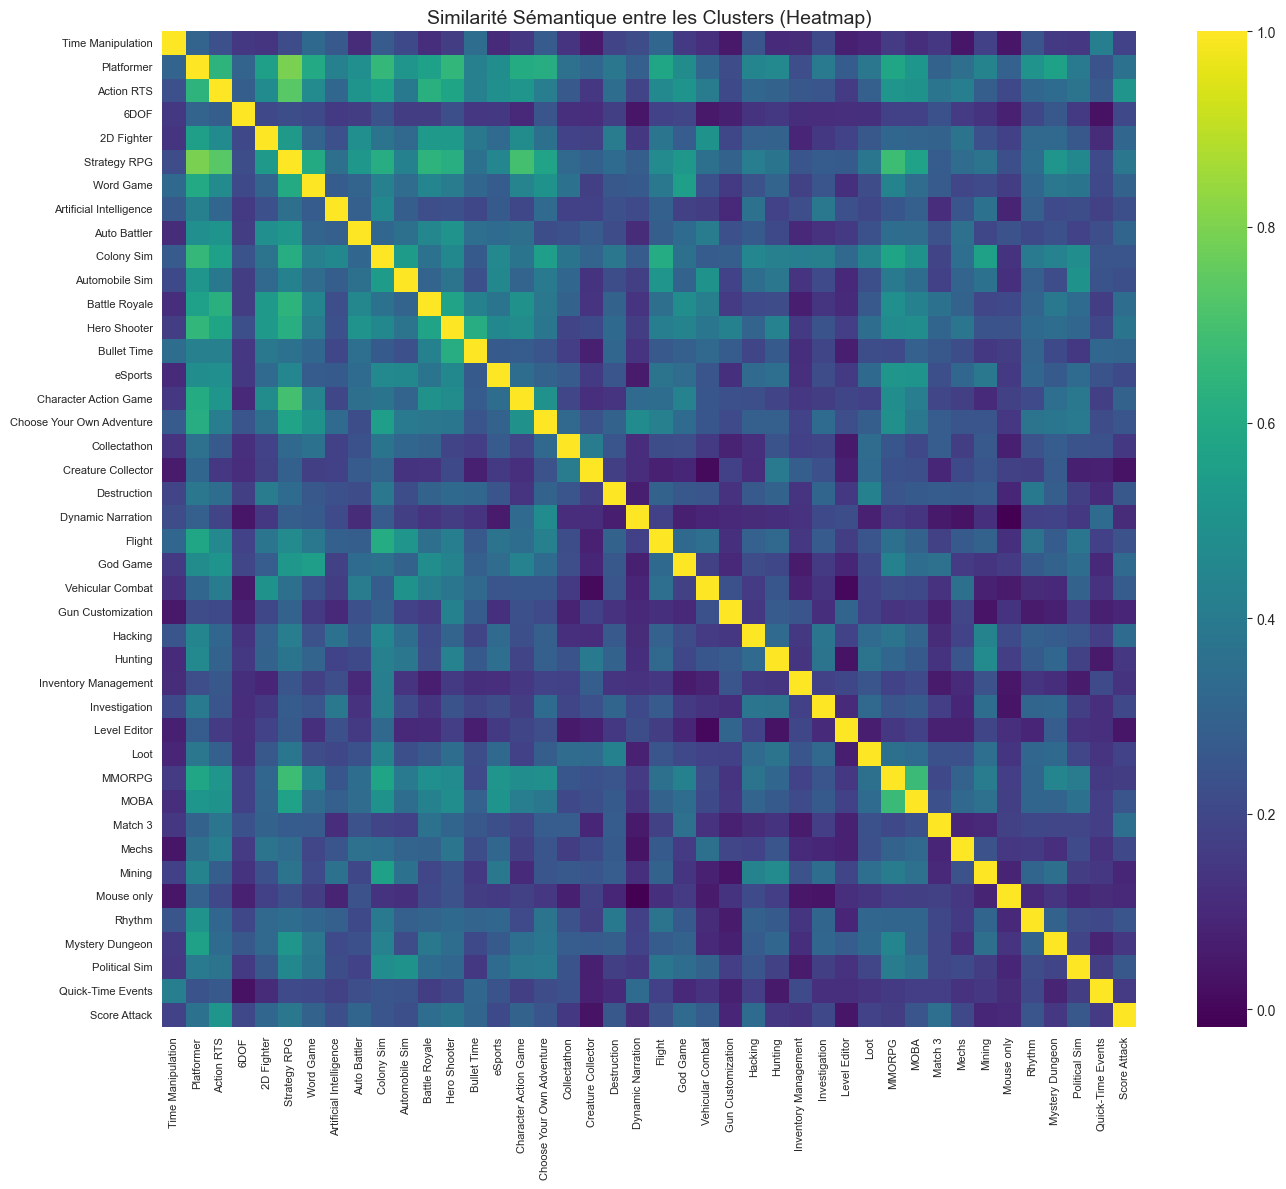

In [13]:
print("\nCalcul de la matrice de similarité entre clusters...")

cluster_centroids = []
cluster_ids = sorted(clusters.keys())
cluster_labels = [cluster_names_nlp[cid] for cid in cluster_ids]

for cid in cluster_ids:
    tags_in_cluster = clusters[cid]
    centroid = df_embeddings.loc[tags_in_cluster].mean(axis=0)
    cluster_centroids.append(centroid)

cluster_centroids_matrix = np.array(cluster_centroids)
similarity_matrix = cosine_similarity(cluster_centroids_matrix)

plt.figure(figsize=(14, 12))
sns.heatmap(similarity_matrix, xticklabels=cluster_labels, yticklabels=cluster_labels, cmap='viridis', annot=False)
plt.title("Similarité Sémantique entre les Clusters (Heatmap)", fontsize=14)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
save_plot('plot')
plt.show()

*On peut voir qu'il existe certains liens sémantiques forts entre certains clusters, ce qui suggère l'existence de "Super-Genres" ou de catégories plus larges. Par exemple, les clusters "MOBA" et "MMORPG" sont proches, ce qui est logique car ils partagent de nombreuses mécaniques et thèmes, cependant il ne peuvent être considérés comme un même genre car ils ont des différences fondamentales (ex: MOBA est plus compétitif et orienté vers des parties courtes, tandis que MMORPG est plus orienté vers l'exploration et le développement de personnage sur le long terme).\
De même pour les cluster "Platformer" et "Action RTS" qui sont également proches, ce qui peut s'expliquer par le fait que de nombreux jeux de plateforme intègrent des éléments d'action et de stratégie en temps réel, mais là encore ils ne peuvent être regroupés dans un même genre car les mécaniques de jeu sont différentes (ex: les jeux de plateforme mettent souvent l'accent sur la précision et le timing, tandis que les jeux d'action RTS mettent l'accent sur la gestion de ressources et la prise de décision rapide).*

## 7. Visualisation Interactive (Plotly)
Une visualisation interactive pour explorer les clusters en détail.

In [14]:
import plotly.express as px

# Préparation des données
df_tsne['Tag'] = df_tsne.index
df_tsne['Cluster Name'] = df_tsne['Cluster'].map(cluster_names_nlp)

# Filtrer le bruit pour la visualisation
df_plotly = df_tsne[df_tsne['Cluster'] != -1].copy()

fig = px.scatter(
    df_plotly,
    x='x', y='y',
    color='Cluster Name',
    hover_name='Tag',
    hover_data=['Cluster Name'],
    title='Carte Sémantique Interactive des Tags Steam',
    template='plotly_white',
    width=1100, height=800
)

fig.update_traces(marker=dict(size=6, opacity=0.8))
fig.update_layout(showlegend=False)
fig.show()

*On arrive toujours à deviner la logique des clusters dans ce qui montre bien la cohérence sémantique de ces derniers, cependant, on peut aussi découvrir des connexions inattendues entre certains tags qui peuvent être présents dans différents clusters, ce qui suggère que certains tags sont plus transversaux et peuvent être associés à plusieurs genres ou mécaniques de jeu.\
Par exemple, "Artificial Intelligence" ce superpose pratiquement avec "Automation".\
Cependant, l'exemple le plus flagrant demeure "Beat'Em Up" qui ce superpose avec "Shoot'Em Up", ce qui suggère que ces deux tags sont très proches sémantiquement et pourraient être regroupés dans un même cluster, ou du moins être considérés comme des sous-genres d'un même genre plus large alors que fondamentalement, ils sont différents (ex: les jeux de type "Beat'Em Up" mettent souvent l'accent sur le combat rapproché et les combos, tandis que les jeux de type "Shoot'Em Up" mettent l'accent sur le tir et l'esquive).\
Ainsi, cette visualisation interactive permet d'explorer en détail les relations entre les tags et de découvrir des connexions qui ne sont pas immédiatement évidentes à partir de l'analyse de graphe ou du clustering, ce qui peut être précieux pour affiner la taxonomie ou pour inspirer de nouvelles idées de classification.*

## Conclusion

L'intégration du **Deep Learning (Sentence-BERT)** et des analyses sémantiques avancées a permis de transformer une simple liste de tags en une taxonomie structurée et cohérente, tout en révélant des nuances importantes.

**Synthèse des observations :**

1.  **Nuance entre Popularité et Sémantique** : La comparaison entre les leaders de graphe (centralité) et les leaders NLP (sémantique) montre que si les résultats sont souvent proches, le NLP tend à identifier des termes plus descriptifs et spécifiques (ex: *Platformer* au lieu de *Action*), là où l'analyse de graphe favorise les tags très fréquents et génériques.

2.  **Cohérence et Taille des Clusters** : L'analyse de la variance intra-cluster confirme que les petits clusters (*Rhythm*, *Automobile Sim*) sont sémantiquement très précis. À l'inverse, les grands clusters (*Platformer*, *Strategy RPG*) sont plus hétérogènes et contiennent parfois des tags transversaux (ex: *Character Customization*) qui diluent leur cohérence thématique.

3.  **Super-Genres et Distinctions Fines** : La Heatmap et la visualisation interactive mettent en évidence des "Super-Genres" (ex: proximité entre *MOBA* et *MMORPG*, ou *Beat'Em Up* et *Shoot'Em Up*). Bien que sémantiquement proches, ces genres conservent des différences mécaniques fondamentales (durée de partie, type de gameplay) qui justifient leur séparation, soulignant la capacité du modèle à capturer des proximités thématiques tout en respectant les frontières ludiques.

4.  **Exploration et Connexions Inattendues** : La visualisation interactive permet de repérer des superpositions surprenantes (ex: *Artificial Intelligence* et *Automation*) et des tags transversaux. Cela offre aux game designers un outil puissant pour naviguer dans l'espace des mécaniques, affiner la taxonomie ou trouver des inspirations hybrides.

En somme, cette approche hybride valide la structure issue de la folksonomie tout en apportant une couche de compréhension sémantique qui permet de mieux qualifier les genres et d'identifier les relations subtiles entre eux.